# 10. Disjunctive Kriging 


**Dataset:** Jura geochemical survey (`data/jura_data.csv`, 359 samples) + prediction grid (`data/jura_grid.csv`)

**Target:** Cadmium (`Cd`, mg/kg)

**Library:** `pygstat.disjunctive_kriging` — Hermite-polynomial disjunctive kriging (Matheron, 1976; Rivoirard, 1994)


***
## Table of Contents

1. [Overview](#1-overview)
2. [How pygstat Implements DK](#2-how-pygstat-implements-dk)
3. [Python Setup](#3-python-setup)
4. [Load and Explore the Jura Cadmium Data](#4-load-and-explore-the-jura-cadmium-data)
5. [Gaussian Anamorphosis and Hermite Coefficients](#5-gaussian-anamorphosis-and-hermite-coefficients)
6. [Fit Disjunctive Kriging](#6-fit-disjunctive-kriging)
7. [Validate DK vs Ordinary Kriging](#7-validate-dk-vs-ordinary-kriging)
8. [Predict Cd on the Jura Grid](#8-predict-cd-on-the-jura-grid)
9. [Probability Maps of Exceedance](#9-probability-maps-of-exceedance)
10. [CPU vs GPU Disjunctive Kriging Timing](#10-cpu-vs-gpu-disjunctive-kriging-timing)
11. [Summary and Conclusions](#11-summary-and-conclusions)
12. [Resources](#12-resources)


***
## 1. Overview

Disjunctive kriging (DK) is a **nonlinear** geostatistical estimator (Matheron, 1976). Where ordinary/simple kriging give you the best estimate that's a *linear* combination of the data, $\hat Z(x_0)=\sum_i \lambda_i Z(x_i)$, DK gives you the best estimate that's a *sum of separate functions of each datum*,

$$
\hat Z_{DK}(x_0) = \sum_{i=1}^n f_i\big(Z(x_i)\big),
$$

optimized in the same mean-square sense as kriging. This is a strictly richer class than linear combinations, and — under one specific, tractable model — turns out to be computable almost as cheaply as ordinary kriging.

### Why bother

The truly optimal estimator (minimum mean-square error, full stop) is the conditional expectation $E[Z(x_0)\mid Z(x_1),\dots,Z(x_n)]$. That requires the entire $(n+1)$-variate joint distribution, which is never available in practice. Kriging sidesteps this by restricting to linear estimators, which is optimal *only if the field is multivariate Gaussian*. Real variables — ore grades, pollutant concentrations, rainfall — are usually skewed, so linear kriging leaves real, nonlinear structure on the table. DK is the practical middle ground: richer than linear, but still computable.

### Step 1 — Gaussian anamorphosis

Transform the raw variable to a standard Gaussian one via the (empirical) anamorphosis function $\varphi$:

$$
Z(x) = \varphi\big(Y(x)\big), \qquad Y(x) \sim N(0,1),
$$

built exactly the way `pygstat.nscore` already does for sequential Gaussian simulation: $Y = \Phi^{-1}\!\big(F_Z(Z)\big)$, matching empirical quantiles of $Z$ to quantiles of a standard normal.

### Step 2 — Hermite polynomial expansion

The anamorphosis is expanded in the (normalized) Hermite polynomials $H_n$, which are orthonormal under the standard Gaussian density:

$$
\varphi(y) = \sum_{n=0}^{\infty} \varphi_n H_n(y), \qquad
E\big[H_n(Y)H_m(Y)\big] = \delta_{nm}.
$$

The $H_n$ satisfy the recurrence

$$
H_0(y)=1,\quad H_1(y) = -y,\quad
H_n(y) = -\frac{1}{\sqrt n}\Big(y\,H_{n-1}(y) + \sqrt{n-1}\,H_{n-2}(y)\Big),
$$

and the coefficients $\varphi_n = E[Z\,H_n(Y)]$ are estimated numerically from the empirical anamorphosis table.

### Step 3 — the bi-Gaussian model (the key assumption)

DK assumes that for **any** two locations, $\big(Y(x),Y(x')\big)$ is *bivariate* Gaussian with correlation $\rho(h)$, $h=\|x-x'\|$ — stronger than each $Y(x)$ merely having a Gaussian marginal. Under this model, Hermite polynomials have a remarkable diagonalizing property:

$$
E\big[H_n(Y(x))\,H_m(Y(x'))\big] = \delta_{nm}\,\rho(h)^n .
$$

Different orders are uncorrelated *even across different locations*, and same-order terms decorrelate as $\rho(h)$ raised to the power of the order. This is what makes DK tractable.

### Step 4 — krige each Hermite order separately

Because $Z(x_0)=\sum_n \varphi_n H_n(Y(x_0))$ and the orders are mutually orthogonal at every lag, the optimal combination reduces to **simple-kriging each order independently**, using covariance $\rho(h)^n$:

$$
\big[H_n(Y(x_0))\big]^*_{SK} = \sum_{i=1}^n \lambda_i^{(n)} H_n\big(Y(x_i)\big),
\qquad
\sum_{j} \lambda_j^{(n)}\,\rho(x_i-x_j)^n = \rho(x_i-x_0)^n \ \ \forall i.
$$

You solve $N{+}1$ *separate* SK systems (one per order $n=0,\dots,N$), each still an $n\times n$ system exactly like ordinary kriging — just with the correlogram raised to a different power each time. Then:

$$
\boxed{\;\hat Z_{DK}(x_0) = \sum_{n=0}^{N} \varphi_n\,\big[H_n(Y(x_0))\big]^*_{SK}\;}
$$

Order $n=0$ ($H_0=1$) just contributes the mean $\varphi_0$. Truncating at $n=1$ recovers something close to plain kriging of the Gaussian-transformed variable — DK's real value comes from the $n\ge 2$ terms capturing genuine nonlinear structure that linear kriging can't.

### Where DK really earns its keep: nonlinear functionals

The same machinery estimates *any* nonlinear function of $Z(x_0)$, reusing the identical kriged components $[H_n(Y(x_0))]^*$ — you just swap in different coefficients. The classic example is **probability of exceeding a cutoff** (mining recoverable reserves, contamination risk maps): with $y_c=\Phi^{-1}(F_Z(z_c))$,

$$
\mathbf 1_{Z(x_0)>z_c} = \mathbf 1_{Y(x_0)>y_c} = \sum_{n=0}^\infty \chi_n(y_c)\,H_n\big(Y(x_0)\big),
\qquad
\chi_n(y_c) = \frac{g(y_c)\,H_{n-1}(y_c)}{\sqrt n}\ (n\ge1),\quad \chi_0=\bar\Phi(y_c),
$$

($g$ = standard normal density), giving

$$
\widehat{P}\big(Z(x_0)>z_c\mid\text{data}\big) = \sum_{n=0}^N \chi_n(y_c)\,\big[H_n(Y(x_0))\big]^*_{SK}.
$$

Krige the Hermite components **once**; recombine them for the mean, an exceedance probability at any cutoff, a truncated/recoverable mean $E[Z\cdot\mathbf 1_{Z>z_c}]$ for grade-tonnage curves, etc. — this modularity is DK's most practically useful feature.

### DK vs. OK vs. true conditional expectation

| Estimator | Optimal among... | Cost |
|---|---|---|
| Ordinary/Simple Kriging | linear combinations $\sum\lambda_i Z_i$ | one $n\times n$ system |
| Disjunctive Kriging | sums of separate functions $\sum f_i(Z_i)$ | $N{+}1$ systems (same size, powers of $\rho$) |
| True conditional expectation $E[Z_0\mid\mathbf Z]$ | *any* function of the joint data | needs the full joint density — generally infeasible |

If the field is genuinely multi-Gaussian, DK's point estimate of $Z(x_0)$ itself collapses to simple kriging (all information is in $n=1$) — but DK still adds real value there too, since a nonlinear functional like an exceedance indicator is never linear in $Y$, so the higher-order terms still matter.

### Caveats
- Everything rests on the **bi-Gaussian model** for $Y$, checked in practice via things like the madogram or scatterplots of $Y$-pairs at varying lags — it's an assumption, not a consequence of the anamorphosis alone.
- The Hermite series is truncated at some $N$ (often 20–50 terms); coefficients $\varphi_n$ typically decay fast, so truncation error is usually small but should be checked.
- Point-support DK doesn't handle **change of support** (e.g., block averages) correctly on its own — that needs the *discrete Gaussian model* extension, standard in mining reserve estimation.

This tutorial applies that recipe to **cadmium (Cd)** in the Swiss Jura using `pygstat.DisjunctiveKriging`. Cadmium is right-skewed, so a linear interpolator of the raw grades is not the full story — exactly the setting DK was designed for.

| Step | What we do |
|---|---|
| Data | Load `jura_data.csv` (359 samples) and `jura_grid.csv` (~6 000 prediction nodes) |
| Split | Stratified 70% / 30% train–test split by **Landuse** (`random_state=42`) |
| Anamorphosis | Normal-score transform of Cd; Hermite expansion of $\varphi$ |
| DK | Fit `DisjunctiveKriging` (spherical $Y$-variogram, $N=20$ Hermite orders) |
| Validation | Held-out RMSE / MAE / $R^2$ vs ordinary kriging of Cd |
| Mapping | $\hat Z_{DK}$ and DK standard error on the Jura grid |
| Probability | $P(\mathrm{Cd} > z_c)$ at 0.50, 1.00, 1.50, 2.00 mg/kg via `predict_proba` |
| CPU / GPU | Time `DisjunctiveKriging` on CPU vs GPU using **sgsim** Jura-like Cd ($n=8{,}000$) |

By the end you will have a nonlinear Cd map, a check that DK agrees with (but is not identical to) ordinary kriging, exceedance-probability surfaces obtained by recombining the *same* kriged Hermite components, and a CPU vs GPU timing of global per-order simple kriging on an **SGS-simulated** Jura-like Cd field with $n > 5{,}000$.


***
## 2. How pygstat Implements DK

`pygstat.DisjunctiveKriging` follows the four-step recipe above, reusing pieces already in the library:

| Step | Object | Role |
|---|---|---|
| Anamorphosis | `pygstat.nscore.nscore_forward` | $Y = \Phi^{-1}(F_Z(Z))$, same table as SGSIM |
| Hermite basis | `hermite_polynomials(y, n_max)` | Orthonormal $H_0,\ldots,H_N$ |
| Coefficients | `phi_ = mean(Z * H_n(Y))` | $\varphi_n = E[Z\,H_n(Y)]$ |
| $Y$-variogram | `pygstat.Variogram` | One spherical (or other) fit on $Y$ |
| Per-order SK | `SimpleKriging` + `_OrderVariogram` | Covariance $\rho_Y(h)^n$ for order $n$ |
| Point estimate | `predict()` | $\sum_n \varphi_n\,[H_n(Y(x_0))]^*_{SK}$ |
| Exceedance | `predict_proba(cutoffs)` | $\sum_n \chi_n(y_c)\,[H_n(Y(x_0))]^*_{SK}$ |

**Sign convention.** The Overview quotes the physicists' recurrence with $H_1(y)=-y$. `pygstat` uses the equivalent *orthonormal probabilists'* convention implemented in `hermite_polynomials`:

$$
H_0=1,\qquad H_1(y)=y,\qquad
H_n(y)=\frac{1}{\sqrt n}\Big(y\,H_{n-1}(y)-\sqrt{n-1}\,H_{n-2}(y)\Big),
$$

so that $E[H_n(Y)H_m(Y)]=\delta_{nm}$ for $Y\sim N(0,1)$. Odd-order polynomials differ from the Overview by a global sign; the fitted $\varphi_n$ absorb that sign, and the reconstructed $\varphi(y)$ is the same.

**Variance.** Under the bi-Gaussian model, kriging errors of different Hermite orders are uncorrelated, so

$$
\mathrm{Var}\big[Z(x_0)-\hat Z_{DK}(x_0)\big]
= \sum_{n=0}^{N} \varphi_n^2\,\mathrm{Var}\big[H_n(Y(x_0))-[H_n(Y(x_0))]^*_{SK}\big].
$$

`predict(..., return_variance=True)` returns the square root of that sum (the DK standard error).

**GPU.** `use_gpu='auto'|True|False` is resolved once (verified CuPy kernel, not just `import cupy`) and forwarded to the $Y$-variogram and every per-order `SimpleKriging`. DK is **global** SK — GPU work scales with $n_{\mathrm{train}}^3$, not $n_{\mathrm{pred}}$. Section 10 times that path on simulated Jura-like Cd.


***
## 3. Python Setup

### 3.1 CPU and GPU

`DisjunctiveKriging` simple-kriges each Hermite order **globally** (one $n\times n$ covariance among the training points per order $n=1\ldots N$). The expensive steps are those per-order `SimpleKriging.predict` calls: the $n\times n$ covariance, the $n_{\mathrm{pred}}\times n$ covariance to the targets, and the linear solve. The $Y$-variogram's empirical semivariogram can also run on GPU.

| Argument | What it controls |
|----------|------------------|
| `use_gpu` | $Y$-variogram pair distances and every per-order `SimpleKriging` (NumPy or CuPy). |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the result in `USE_GPU`. `DisjunctiveKriging(...)` / `OrdinaryKriging(...)` / `Variogram(...)` calls below pass `use_gpu=USE_GPU`. The Jura maps in §6–§9 use the 359-sample survey; **§10** times the same estimator on an **SGS-simulated** Jura-like Cd field with $n_{\mathrm{train}} > 5{,}000$.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.modules.setdefault("tensorflow", None)
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skew
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pygstat
from pygstat import Variogram, OrdinaryKriging, DisjunctiveKriging, sgsim
from pygstat.disjunctive_kriging import (
    hermite_polynomials,
    hermite_indicator_coefficients,
)
from pygstat.nscore import nscore_forward
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

print("pygstat version:", pygstat.__version__)

# ── DisjunctiveKriging per-order SimpleKriging: CPU / GPU dispatch (CuPy) ────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`).
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — per-order SimpleKriging on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


pygstat version: 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — per-order SimpleKriging on GPU
use_gpu         : True


***
## 4. Load and Explore the Jura Cadmium Data

The **Jura dataset** (Goovaerts, 1997) contains 359 soil samples of heavy metals in the Swiss Jura. We model **Cd** at the sample locations and predict it on the dense lattice in `jura_grid.csv` (~6 000 nodes covering the survey area).

Cadmium is the classic skewed soil-metal variable in this survey: a linear interpolator of the raw grades (Tutorial 04) is a useful baseline, but DK's Hermite expansion is built for exactly this kind of histogram. Land-use codes in the sample file are integers (`1`–`4`); the stratified split uses that `Landuse` column.


In [2]:
df = pd.read_csv("../data/jura_data.csv")
grid = pd.read_csv("../data/jura_grid.csv")

print("Samples:", df.shape, "  Grid:", grid.shape)
print("Sample columns:", list(df.columns))
print("Grid columns:  ", list(grid.columns))
df.head()


Samples: (359, 12)   Grid: (5957, 5)
Sample columns: ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock', 'Cd', 'Co', 'Cr', 'Cu', 'Ni', 'Pb', 'Zn']
Grid columns:   ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock']


,Unnamed: 0,Xloc,Yloc,Landuse,Rock,Cd,Co,Cr,Cu,Ni,Pb,Zn
0,1,2.386,3.077,3,3,1.740,9.32,38.32,25.72,21.32,77.36,92.56
1,2,2.544,1.972,2,2,1.335,10.00,40.20,24.76,29.72,77.88,73.56
2,3,2.807,3.347,2,3,1.610,10.60,47.00,8.88,21.40,30.80,64.80
3,4,4.308,1.933,3,2,2.150,11.92,43.52,22.70,29.72,56.40,90.00
4,5,4.383,1.081,3,5,1.565,16.32,38.52,34.32,26.20,66.40,88.40


In [3]:
target = "Cd"
x_col, y_col = "Xloc", "Yloc"
strata_col = "Landuse"

coords = df[[x_col, y_col]].values
z = df[target].values.astype(float)
grid_coords = grid[[x_col, y_col]].values

print(f"\n{target} (mg/kg) summary:")
print(df[target].describe().round(3))
print(f"Skewness: {skew(z):.3f}")
print(f"\nLanduse counts:\n{df[strata_col].value_counts().sort_index().to_string()}")



Cd (mg/kg) summary:
count    359.000
mean       1.288
std        0.859
min        0.135
25%        0.653
50%        1.100
75%        1.680
max        5.129
Name: Cd, dtype: float64
Skewness: 1.472

Landuse counts:
Landuse
1     51
2     82
3    218
4      8


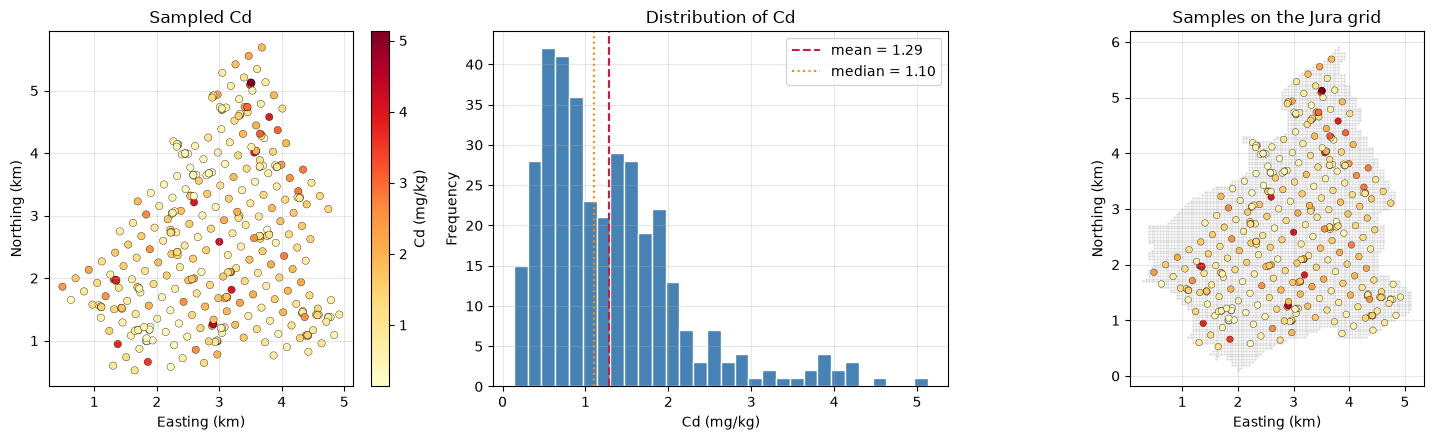

Grid extent: X [0.30, 5.10], Y [0.10, 5.90] km  (5957 nodes)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sc = axes[0].scatter(
    df[x_col], df[y_col], c=z, cmap="YlOrRd", s=28,
    edgecolors="k", linewidths=0.25,
)
plt.colorbar(sc, ax=axes[0], label=f"{target} (mg/kg)", fraction=0.046, pad=0.04)
axes[0].set_title(f"Sampled {target}")
axes[0].set_xlabel("Easting (km)")
axes[0].set_ylabel("Northing (km)")
axes[0].set_aspect("equal")

axes[1].hist(z, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(z.mean(), color="crimson", ls="--", label=f"mean = {z.mean():.2f}")
axes[1].axvline(np.median(z), color="darkorange", ls=":", label=f"median = {np.median(z):.2f}")
axes[1].set_title(f"Distribution of {target}")
axes[1].set_xlabel(f"{target} (mg/kg)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].scatter(grid[x_col], grid[y_col], s=2, c="0.85", marker=".")
axes[2].scatter(
    df[x_col], df[y_col], c=z, cmap="YlOrRd", s=22,
    edgecolors="k", linewidths=0.25,
)
axes[2].set_title("Samples on the Jura grid")
axes[2].set_xlabel("Easting (km)")
axes[2].set_ylabel("Northing (km)")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

print(
    f"Grid extent: X [{grid[x_col].min():.2f}, {grid[x_col].max():.2f}], "
    f"Y [{grid[y_col].min():.2f}, {grid[y_col].max():.2f}] km  ({len(grid)} nodes)"
)


***
## 5. Gaussian Anamorphosis and Hermite Coefficients

Before fitting the full DK interpolator, we look at the two ingredients that make it nonlinear: the **normal-score transform** of Cd and the **Hermite expansion** of that anamorphosis.

### 5.1 Normal-score transform

`nscore_forward` matches empirical quantiles of $Z$ to those of $N(0,1)$. The resulting $Y$ should look approximately standard Gaussian (the *marginal* is Gaussian by construction; the *bivariate* Gaussian assumption of Step 3 is a separate check).


Y mean / std          : 0.0000 / 0.9982
Y min / max           : -2.990 / 2.990
Lookup table length   : 276 unique Cd values


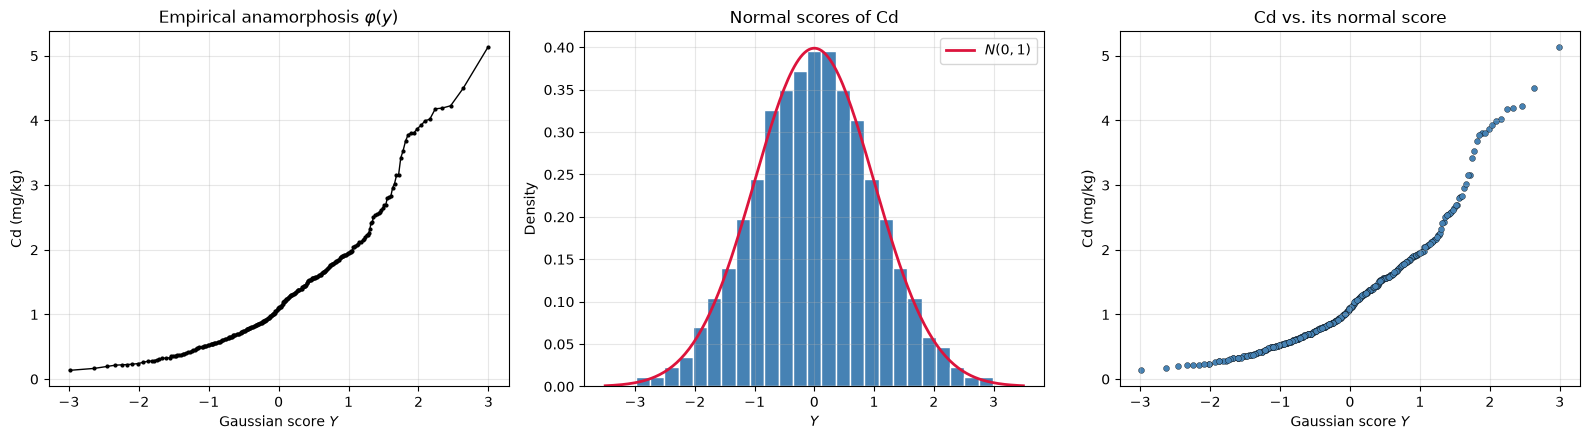

In [5]:
y_all, z_sorted, ns_sorted = nscore_forward(z, tails="linear")

print(f"Y mean / std          : {y_all.mean():.4f} / {y_all.std():.4f}")
print(f"Y min / max           : {y_all.min():.3f} / {y_all.max():.3f}")
print(f"Lookup table length   : {len(z_sorted)} unique Cd values")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(ns_sorted, z_sorted, "k.-", ms=4, lw=1)
axes[0].set_xlabel("Gaussian score $Y$")
axes[0].set_ylabel("Cd (mg/kg)")
axes[0].set_title(r"Empirical anamorphosis $\varphi(y)$")

axes[1].hist(y_all, bins=25, color="steelblue", edgecolor="white", density=True)
yy = np.linspace(-3.5, 3.5, 200)
axes[1].plot(yy, norm.pdf(yy), "crimson", lw=2, label="$N(0,1)$")
axes[1].set_title("Normal scores of Cd")
axes[1].set_xlabel("$Y$")
axes[1].set_ylabel("Density")
axes[1].legend()

axes[2].scatter(y_all, z, c="steelblue", s=18, edgecolors="k", linewidths=0.25)
axes[2].set_xlabel("Gaussian score $Y$")
axes[2].set_ylabel("Cd (mg/kg)")
axes[2].set_title("Cd vs. its normal score")

plt.tight_layout()
plt.show()


### 5.2 Hermite polynomials and the indicator expansion

The first few orthonormal Hermite polynomials, and a truncated reconstruction of the step function $\mathbf 1_{Y>y_c}$ from `hermite_indicator_coefficients`. The truncated series rings near the jump (Gibbs phenomenon) — that is why `predict_proba` clips probabilities to $[0, 1]$, and why more orders improve the $L^2$ fit even if a single point near $y_c$ can overshoot.


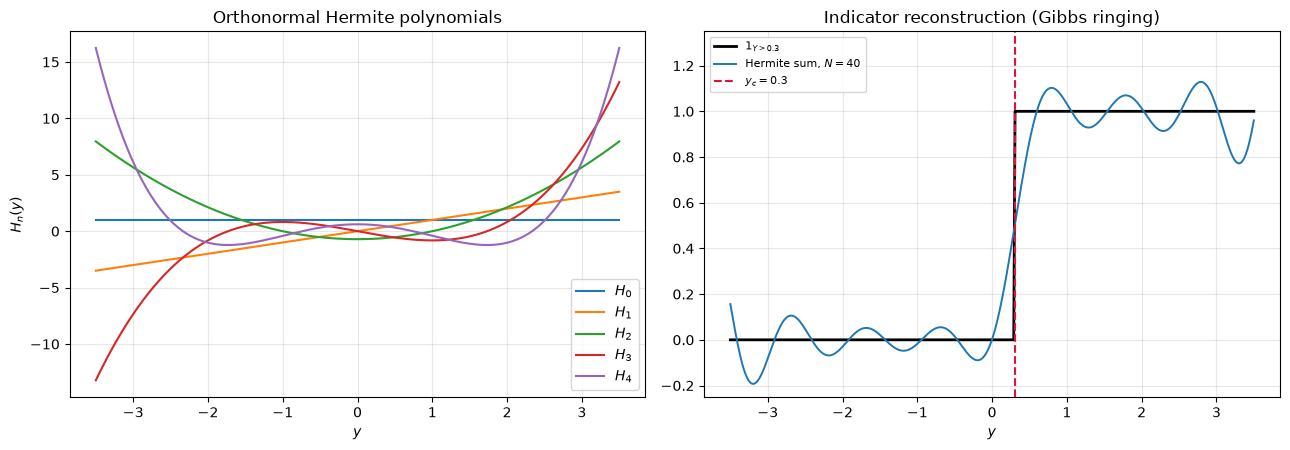

chi_0 (should equal 1-Phi(yc) = 0.3821): 0.3821
H_0(0) = 1.0
H_1([0, 1, 2]) = [0. 1. 2.]
H_2(y) = (y^2 - 1)/sqrt(2) at y=0,1,2: [-0.70710678  0.          2.12132034]


In [6]:
yy = np.linspace(-3.5, 3.5, 400)
H = hermite_polynomials(yy, 4)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for n in range(5):
    axes[0].plot(yy, H[n], label=f"$H_{n}$")
axes[0].set_xlabel("$y$")
axes[0].set_ylabel("$H_n(y)$")
axes[0].set_title("Orthonormal Hermite polynomials")
axes[0].legend()

yc = 0.3
n_show = 40
chi = hermite_indicator_coefficients(yc, n_show)
H_yy = hermite_polynomials(yy, n_show)
recon = (chi[:, None] * H_yy).sum(axis=0)
true_ind = (yy > yc).astype(float)

axes[1].plot(yy, true_ind, "k-", lw=2, label=fr"$1_{{Y > {yc}}}$")
axes[1].plot(yy, recon, color="tab:blue", lw=1.4, label=f"Hermite sum, $N={n_show}$")
axes[1].axvline(yc, color="crimson", ls="--", label=fr"$y_c={yc}$")
axes[1].set_ylim(-0.25, 1.35)
axes[1].set_xlabel("$y$")
axes[1].set_title("Indicator reconstruction (Gibbs ringing)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"chi_0 (should equal 1-Phi(yc) = {1 - norm.cdf(yc):.4f}): {chi[0]:.4f}")
print(f"H_0(0) = {hermite_polynomials(np.array([0.0]), 2)[0, 0]:.1f}")
print(f"H_1([0, 1, 2]) = {hermite_polynomials(np.array([0.0, 1.0, 2.0]), 2)[1]}")
print(f"H_2(y) = (y^2 - 1)/sqrt(2) at y=0,1,2: "
      f"{hermite_polynomials(np.array([0.0, 1.0, 2.0]), 2)[2]}")


***
## 6. Fit Disjunctive Kriging

A purely random split can leave land-use class `4` (only 8 samples) under-represented in the test set. **Stratified random sampling** by `Landuse` keeps the class mix in both sets (`random_state=42`, same convention as Tutorials 03–06).

`DisjunctiveKriging.fit` then, on the **training** samples only:

1. builds the Gaussian anamorphosis of Cd,
2. estimates $\varphi_0,\ldots,\varphi_N$,
3. fits a spherical variogram to $Y$,
4. fits one `SimpleKriging` per Hermite order $n=1,\ldots,N$.

We use $N=20$ terms — the default, and the order used in `tests/test_disjunctive_kriging.py`. `explained_variance_ratio_` is $\sum_{n\ge 1}\varphi_n^2 / \mathrm{Var}(Z)$, the fraction of Cd's variance captured by the truncated expansion (it should sit near 1).


In [7]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(sss.split(df, df[strata_col]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

coords_train = df_train[[x_col, y_col]].values
z_train = df_train[target].values.astype(float)
coords_test = df_test[[x_col, y_col]].values
z_test = df_test[target].values.astype(float)

print(f"Train: {len(df_train)}    Test: {len(df_test)}")
print("Train Landuse counts:")
print(df_train[strata_col].value_counts().sort_index().to_string())
print("Test  Landuse counts:")
print(df_test[strata_col].value_counts().sort_index().to_string())


Train: 251    Test: 108
Train Landuse counts:
Landuse
1     36
2     57
3    152
4      6
Test  Landuse counts:
Landuse
1    15
2    25
3    66
4     2


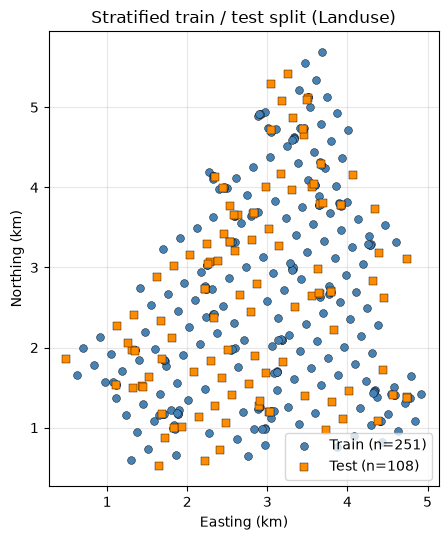

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(
    df_train[x_col], df_train[y_col], c="steelblue", s=32,
    edgecolors="k", linewidths=0.3, label=f"Train (n={len(df_train)})", zorder=3,
)
ax.scatter(
    df_test[x_col], df_test[y_col], c="darkorange", s=32, marker="s",
    edgecolors="k", linewidths=0.3, label=f"Test (n={len(df_test)})", zorder=3,
)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_title("Stratified train / test split (Landuse)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [9]:
N_HERMITE = 20

dk = DisjunctiveKriging(
    model="spherical",
    n_hermite=N_HERMITE,
    tails="linear",
    use_gpu=USE_GPU,
    variogram_kwargs={"n_lags": 15, "estimator": "matheron"},
)
dk.fit(coords_train, z_train)

vg_y = dk.y_variogram_
print("Disjunctive Kriging fitted")
print(f"  n_hermite              : {dk.n_hermite}")
print(f"  phi_[0] (mean Cd)      : {dk.phi_[0]:.4f}   (sample mean {z_train.mean():.4f})")
print(f"  explained_variance_ratio_: {dk.explained_variance_ratio_:.4f}")
print(f"  Y-variogram model      : {vg_y.model}")
print(f"  Y fitted params [C0, C, a]: {np.round(vg_y.fitted_params, 4)}")
print(f"  SK models (orders 1..N): {len(dk.krige_by_order_)}")


Disjunctive Kriging fitted
  n_hermite              : 20
  phi_[0] (mean Cd)      : 1.2995   (sample mean 1.2995)
  explained_variance_ratio_: 1.0196
  Y-variogram model      : spherical
  Y fitted params [C0, C, a]: [0.5905 0.4494 1.3368]
  SK models (orders 1..N): 20


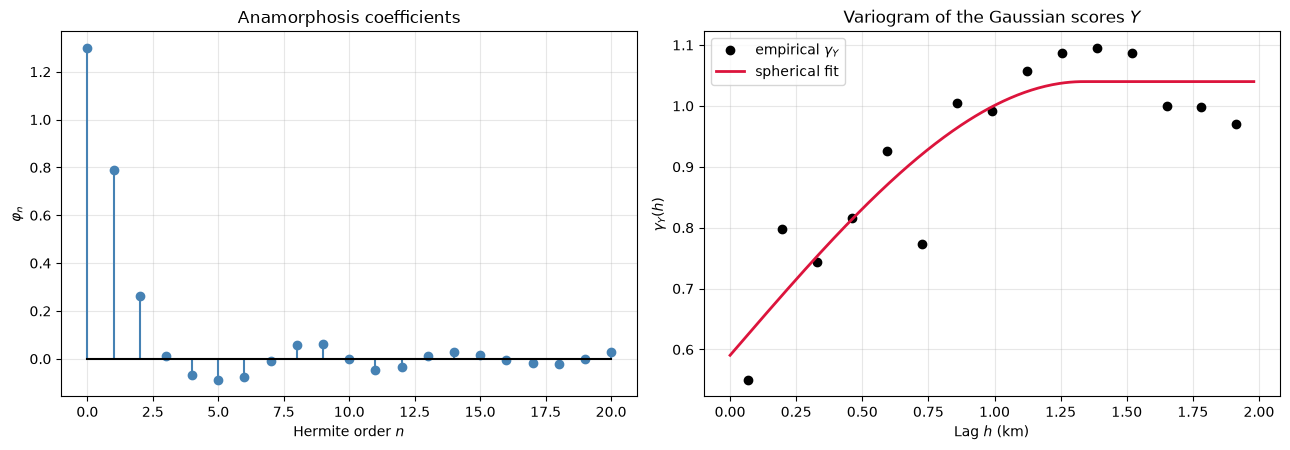

Cumulative explained-variance by max order n:
  n =  1 : 0.8785
  n =  2 : 0.9756
  n =  5 : 0.9928
  n = 10 : 1.0109
  n = 20 : 1.0196


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

orders = np.arange(dk.n_hermite + 1)
axes[0].stem(orders, dk.phi_, linefmt="steelblue", markerfmt="o", basefmt="k-")
axes[0].set_xlabel("Hermite order $n$")
axes[0].set_ylabel(r"$\varphi_n$")
axes[0].set_title("Anamorphosis coefficients")

h_emp = vg_y.lags
g_emp = vg_y.experimental
h_fine = np.linspace(0, vg_y.maxlag, 300)
g_fit = vg_y(h_fine)
axes[1].plot(h_emp, g_emp, "o", color="k", label="empirical $\gamma_Y$")
axes[1].plot(h_fine, g_fit, color="crimson", lw=2, label=f"{vg_y.model} fit")
axes[1].set_xlabel("Lag $h$ (km)")
axes[1].set_ylabel(r"$\gamma_Y(h)$")
axes[1].set_title("Variogram of the Gaussian scores $Y$")
axes[1].legend()

plt.tight_layout()
plt.show()

cum = np.cumsum(dk.phi_[1:] ** 2) / dk.var_z_
print("Cumulative explained-variance by max order n:")
for n in (1, 2, 5, 10, 20):
    if n <= dk.n_hermite:
        print(f"  n = {n:2d} : {cum[n - 1]:.4f}")


***
## 7. Validate DK vs Ordinary Kriging

Predict Cd at the **held-out** 30% of samples. These locations were not used to fit the anamorphosis or the $Y$-variogram, so the scores below are an honest check of interpolation quality.

Ordinary kriging of raw Cd (Tutorial 04) is the linear baseline. DK and OK estimate the same field two different ways — nonlinear via the Hermite expansion of $Y$, versus linear in $Z$ — so they should **correlate strongly** without matching exactly (`tests/test_disjunctive_kriging.py` requires correlation $> 0.9$ on a comparable pair of maps).


In [11]:
z_hat_dk, se_dk_test = dk.predict(coords_test, return_variance=True)

vg_ok = Variogram(
    coords_train, z_train, model="spherical",
    estimator="matheron", n_lags=15, use_gpu=USE_GPU,
)
vg_ok.fit()
ok = OrdinaryKriging(vg_ok, use_gpu=USE_GPU).fit(coords_train, z_train)
z_hat_ok, se_ok_test = ok.predict(coords_test, return_variance=True)


def metrics(obs, pred, name):
    rmse = float(np.sqrt(mean_squared_error(obs, pred)))
    mae = float(mean_absolute_error(obs, pred))
    r2 = float(r2_score(obs, pred))
    me = float(np.mean(pred - obs))
    print(f"{name:22s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  ME={me:+.3f}")
    return rmse, mae, r2, me


print("Held-out test set (Cd, mg/kg)")
metrics(z_test, z_hat_dk, "Disjunctive Kriging")
metrics(z_test, z_hat_ok, "Ordinary Kriging")
print(f"corr(DK, OK) on test   : {np.corrcoef(z_hat_dk, z_hat_ok)[0, 1]:.3f}")
print(f"DK SE  min/mean/max    : {se_dk_test.min():.3f} / {se_dk_test.mean():.3f} / {se_dk_test.max():.3f}")
print(f"OK SE  min/mean/max    : {se_ok_test.min():.3f} / {se_ok_test.mean():.3f} / {se_ok_test.max():.3f}")


Held-out test set (Cd, mg/kg)
Disjunctive Kriging     RMSE=0.774  MAE=0.552  R2=0.240  ME=-0.005
Ordinary Kriging        RMSE=0.765  MAE=0.568  R2=0.258  ME=+0.032
corr(DK, OK) on test   : 0.943
DK SE  min/mean/max    : 0.706 / 0.737 / 0.798
OK SE  min/mean/max    : 0.705 / 0.763 / 0.827


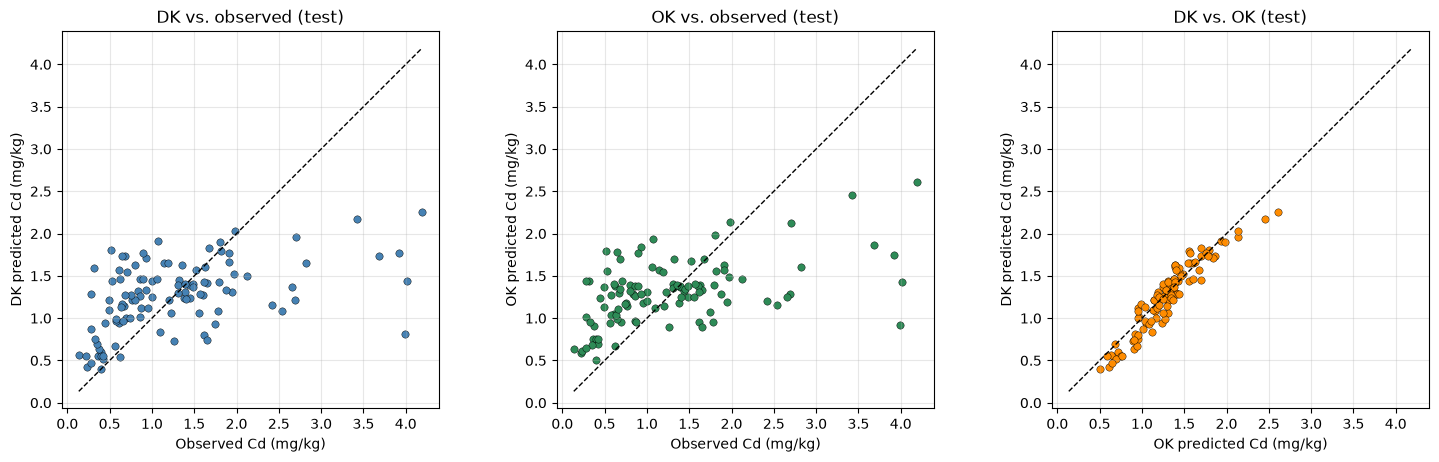

DK RMSE at training locations: 0.077  (should be well below sample SD 0.844)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

lo = min(z_test.min(), z_hat_dk.min(), z_hat_ok.min())
hi = max(z_test.max(), z_hat_dk.max(), z_hat_ok.max())

axes[0].scatter(z_test, z_hat_dk, c="steelblue", edgecolors="k", linewidths=0.3, s=28)
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_xlabel("Observed Cd (mg/kg)")
axes[0].set_ylabel("DK predicted Cd (mg/kg)")
axes[0].set_title("DK vs. observed (test)")
axes[0].set_aspect("equal", adjustable="box")

axes[1].scatter(z_test, z_hat_ok, c="seagreen", edgecolors="k", linewidths=0.3, s=28)
axes[1].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[1].set_xlabel("Observed Cd (mg/kg)")
axes[1].set_ylabel("OK predicted Cd (mg/kg)")
axes[1].set_title("OK vs. observed (test)")
axes[1].set_aspect("equal", adjustable="box")

axes[2].scatter(z_hat_ok, z_hat_dk, c="darkorange", edgecolors="k", linewidths=0.3, s=28)
axes[2].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[2].set_xlabel("OK predicted Cd (mg/kg)")
axes[2].set_ylabel("DK predicted Cd (mg/kg)")
axes[2].set_title("DK vs. OK (test)")
axes[2].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

pred_train = dk.predict(coords_train)
rmse_train = float(np.sqrt(np.mean((pred_train - z_train) ** 2)))
print(f"DK RMSE at training locations: {rmse_train:.3f}  "
      f"(should be well below sample SD {z_train.std():.3f})")


***
## 8. Predict Cd on the Jura Grid

Apply the fitted DK model to every node in `jura_grid.csv`. We keep both the predicted concentration and the DK standard error. Ordinary-kriging predictions on the same grid are stored for a side-by-side map.


In [13]:
pred_dk, se_dk = dk.predict(grid_coords, return_variance=True)
pred_ok, se_ok = ok.predict(grid_coords, return_variance=True)

grid_out = grid.copy()
grid_out["Cd_dk"] = pred_dk
grid_out["Cd_dk_se"] = se_dk
grid_out["Cd_ok"] = pred_ok
grid_out["Cd_ok_se"] = se_ok

print(f"Grid predictions: n = {len(pred_dk)}")
print(
    f"  DK  Cd   min/mean/max : {pred_dk.min():.3f} / {pred_dk.mean():.3f} / {pred_dk.max():.3f} mg/kg"
)
print(
    f"  DK  SE   min/mean/max : {se_dk.min():.3f} / {se_dk.mean():.3f} / {se_dk.max():.3f} mg/kg"
)
print(
    f"  OK  Cd   min/mean/max : {pred_ok.min():.3f} / {pred_ok.mean():.3f} / {pred_ok.max():.3f} mg/kg"
)
print(f"  corr(DK, OK) on grid  : {np.corrcoef(pred_dk, pred_ok)[0, 1]:.3f}")
assert np.isfinite(pred_dk).all() and np.isfinite(se_dk).all()
assert np.all(se_dk >= 0)
grid_out[[x_col, y_col, "Cd_dk", "Cd_dk_se"]].head()


Grid predictions: n = 5957
  DK  Cd   min/mean/max : 0.389 / 1.327 / 2.222 mg/kg
  DK  SE   min/mean/max : 0.705 / 0.746 / 0.846 mg/kg
  OK  Cd   min/mean/max : 0.431 / 1.333 / 2.545 mg/kg
  corr(DK, OK) on grid  : 0.902


,Xloc,Yloc,Cd_dk,Cd_dk_se
0,0.30,1.70,1.035358,0.813334
1,0.35,1.70,1.031119,0.806042
2,0.35,1.75,1.058328,0.805565
3,0.40,1.70,1.029449,0.797894
4,0.40,1.75,1.058222,0.797472


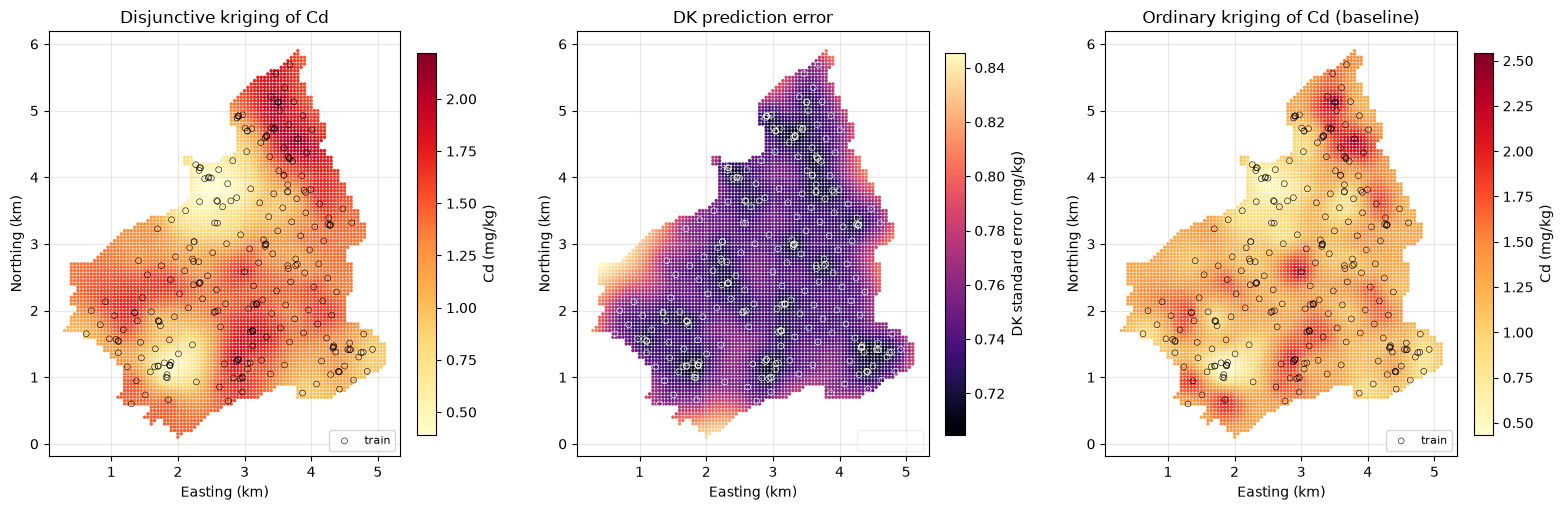

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

sc0 = axes[0].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["Cd_dk"],
    cmap="YlOrRd", s=8, marker=".",
)
axes[0].scatter(
    df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
    s=18, linewidths=0.4, label="train",
)
plt.colorbar(sc0, ax=axes[0], label="Cd (mg/kg)", fraction=0.046, pad=0.04)
axes[0].set_aspect("equal")
axes[0].set_title("Disjunctive kriging of Cd")
axes[0].set_xlabel("Easting (km)")
axes[0].set_ylabel("Northing (km)")
axes[0].legend(loc="lower right", fontsize=8)

sc1 = axes[1].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["Cd_dk_se"],
    cmap="magma", s=8, marker=".",
)
axes[1].scatter(
    df_train[x_col], df_train[y_col], facecolors="none", edgecolors="w",
    s=18, linewidths=0.4, label="train",
)
plt.colorbar(sc1, ax=axes[1], label="DK standard error (mg/kg)", fraction=0.046, pad=0.04)
axes[1].set_aspect("equal")
axes[1].set_title("DK prediction error")
axes[1].set_xlabel("Easting (km)")
axes[1].set_ylabel("Northing (km)")
axes[1].legend(loc="lower right", fontsize=8, labelcolor="white", framealpha=0.3)

sc2 = axes[2].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["Cd_ok"],
    cmap="YlOrRd", s=8, marker=".",
)
axes[2].scatter(
    df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
    s=18, linewidths=0.4, label="train",
)
plt.colorbar(sc2, ax=axes[2], label="Cd (mg/kg)", fraction=0.046, pad=0.04)
axes[2].set_aspect("equal")
axes[2].set_title("Ordinary kriging of Cd (baseline)")
axes[2].set_xlabel("Easting (km)")
axes[2].set_ylabel("Northing (km)")
axes[2].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


***
## 9. Probability Maps of Exceedance

This is where DK earns its keep. `predict_proba` reuses the kriged Hermite components already computed for $\hat Z_{DK}$ and recombines them with the indicator coefficients $\chi_n(y_c)$ at each cutoff $z_c$. No extra kriging systems are solved.

We map $P(\mathrm{Cd} > z_c)$ at **0.50, 1.00, 1.50, and 2.00 mg/kg**. The 1.0 mg/kg cutoff is the same regulatory-style threshold used in Tutorial 09 (soft kriging). Mean exceedance probability across the grid **must decrease** as the cutoff rises (individual nodes can show small order-relation violations near a cutoff — Gibbs ringing of the truncated series — but the aggregate trend is monotonic; see `test_predict_proba_decreases_with_cutoff_on_average`).


In [15]:
cutoffs = [0.50, 1.00, 1.50, 2.00]  # mg/kg
probs = dk.predict_proba(grid_coords, cutoffs)

prob_cols = []
for zc in cutoffs:
    col = f"P_Cd_gt_{zc:.2f}".replace(".", "p")
    grid_out[col] = probs[zc]
    prob_cols.append(col)
    p = probs[zc]
    assert p.shape == (len(grid_coords),)
    assert np.all((p >= 0) & (p <= 1))
    print(
        f"P(Cd > {zc:4.2f})  mean={p.mean():.3f}  min={p.min():.3f}  max={p.max():.3f}"
    )

print()
print("Monotone in the mean?", all(
    probs[cutoffs[i]].mean() > probs[cutoffs[i + 1]].mean()
    for i in range(len(cutoffs) - 1)
))

emp = {zc: float(np.mean(z_train > zc)) for zc in cutoffs}
print("Empirical P(Cd > zc) on training samples:")
for zc, p in emp.items():
    print(f"  {zc:4.2f} mg/kg : {p:.3f}")


P(Cd > 0.50)  mean=0.881  min=0.336  max=1.000
P(Cd > 1.00)  mean=0.560  min=0.000  max=0.880
P(Cd > 1.50)  mean=0.364  min=0.000  max=0.715
P(Cd > 2.00)  mean=0.166  min=0.000  max=0.503

Monotone in the mean? True
Empirical P(Cd > zc) on training samples:
  0.50 mg/kg : 0.873
  1.00 mg/kg : 0.546
  1.50 mg/kg : 0.351
  2.00 mg/kg : 0.155


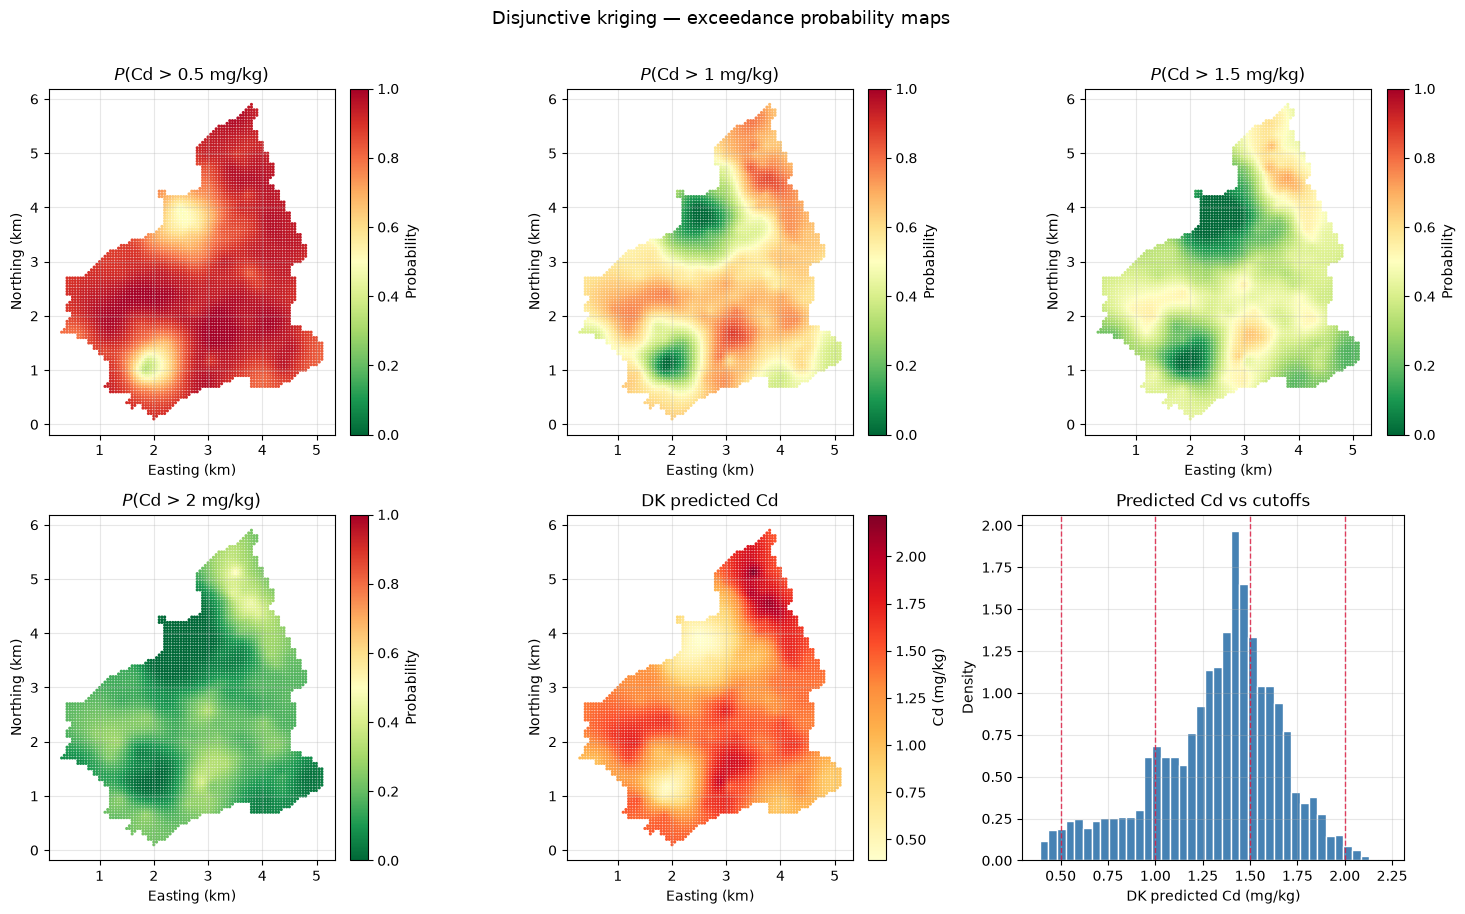

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, zc, col in zip(axes, cutoffs, prob_cols):
    sc = ax.scatter(
        grid_out[x_col], grid_out[y_col], c=grid_out[col],
        cmap="RdYlGn_r", s=6, marker=".", vmin=0, vmax=1,
    )
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Probability")
    ax.set_aspect("equal")
    ax.set_title(f"$P$(Cd > {zc:g} mg/kg)")
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")

sc = axes[4].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["Cd_dk"],
    cmap="YlOrRd", s=6, marker=".",
)
plt.colorbar(sc, ax=axes[4], fraction=0.046, pad=0.04, label="Cd (mg/kg)")
axes[4].set_aspect("equal")
axes[4].set_title("DK predicted Cd")
axes[4].set_xlabel("Easting (km)")
axes[4].set_ylabel("Northing (km)")

axes[5].hist(pred_dk, bins=40, color="steelblue", edgecolor="white", density=True)
for zc in cutoffs:
    axes[5].axvline(zc, color="crimson", ls="--", lw=1, alpha=0.8)
axes[5].set_title("Predicted Cd vs cutoffs")
axes[5].set_xlabel("DK predicted Cd (mg/kg)")
axes[5].set_ylabel("Density")

plt.suptitle("Disjunctive kriging — exceedance probability maps", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [17]:
# Test-set calibration: Brier score of DK probabilities vs. the 0/1 indicator
probs_test = dk.predict_proba(coords_test, cutoffs)
rows = []
for zc in cutoffs:
    ind = (z_test > zc).astype(float)
    p_hat = probs_test[zc]
    brier = float(np.mean((p_hat - ind) ** 2))
    base = float(ind.mean())
    brier_base = float(base * (1.0 - base))  # no-skill: always predict the frequency
    rows.append(
        {
            "cutoff": zc,
            "Brier_DK": brier,
            "Brier_noskill": brier_base,
            "skill": 1.0 - brier / brier_base if brier_base > 0 else np.nan,
            "mean_p_hat": float(p_hat.mean()),
            "empirical": float(ind.mean()),
        }
    )
brier_tbl = pd.DataFrame(rows).round(3)
print("Test-set Brier scores (lower is better; skill > 0 beats the marginal frequency)")
brier_tbl


Test-set Brier scores (lower is better; skill > 0 beats the marginal frequency)


,cutoff,Brier_DK,Brier_noskill,skill,mean_p_hat,empirical
0,0.5,0.087,0.145,0.403,0.847,0.824
1,1.0,0.202,0.250,0.193,0.512,0.509
2,1.5,0.191,0.216,0.116,0.330,0.315
3,2.0,0.099,0.106,0.066,0.153,0.120


***
## 10. CPU vs GPU Disjunctive Kriging Timing

The 359-sample Jura survey is too small to show how DK scales: each Hermite order is a **global** simple-kriging system whose $n\times n$ covariance and solve grow as $O(n_{\mathrm{train}}^3)$. Here we **simulate a Jura-like Cd field** with Sequential Gaussian Simulation (`pygstat.sgsim`) so that $n_{\mathrm{train}} > 5{,}000$, then time `DisjunctiveKriging.fit` + `predict(..., return_variance=True)` on **CPU** (`use_gpu=False`) versus **GPU** (`use_gpu=True`).

Simulation recipe (conditioned on the real 359 samples):

1. Draw $n = 8{,}000$ random locations in the Jura bounding box.
2. Simulate $\log(\mathrm{Cd})$ with `sgsim` (exponential variogram, practical range 1.2 km, conditioned on `data/jura_data.csv`) and back-transform with $\exp(\cdot)$.
3. Time **prefixes** of that cloud ($n_{\mathrm{train}} = 500,\,1{,}000,\,2{,}000,\,4{,}000,\,6{,}000$) predicting a fixed set of $n_{\mathrm{pred}} = 500$ locations.

Because DK is global SK, GPU work scales with **$n_{\mathrm{train}}^3$**, not $n_{\mathrm{pred}}$. We therefore hold the prediction set modest and vary training size — the opposite of k-NN indicator / soft kriging. Timing uses $N=8$ Hermite orders (the Jura maps in §6 still use $N=20$); eight independent SK predicts already dominate the wall time. SGS is sequential CPU work and is **excluded** from the DK times. Variogram fitting inside `fit` **is** included.

Each timing is the **median** of three `fit` + `predict` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped.


Simulating 8,000 Jura-like Cd locations with sgsim
  conditioning : 359 samples from data/jura_data.csv
  vario        : azimuth=0, nugget=0.023, range=1.2 km, exponential, log(Cd)
  sgsim wall   : 58.7 s  (not included in DisjunctiveKriging times)
  simulated Cd : [0.13, 9.91] mg/kg  (Jura observed [0.14, 5.13])

GPU usable : True
Repeats    : 3  (median wall time of DK fit + predict)
n_hermite  : 8  (timing only; mapping in §6 uses N=20)
n_pred     : 500 locations drawn in the Jura bbox
n_train    : [500, 1000, 2000, 4000, 6000]  (prefixes of the 8,000 sgsim locations)

     dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
Jura (sgsim)      500     500     545.9      94.3   5.79×   True
Jura (sgsim)     1000     500    1490.9     160.7   9.28×   True
Jura (sgsim)     2000     500    3556.6     437.2   8.13×   True
Jura (sgsim)     4000     500   13708.8    1793.5   7.64×   True
Jura (sgsim)     6000     500   31583.8    4769.8   6.62×   True


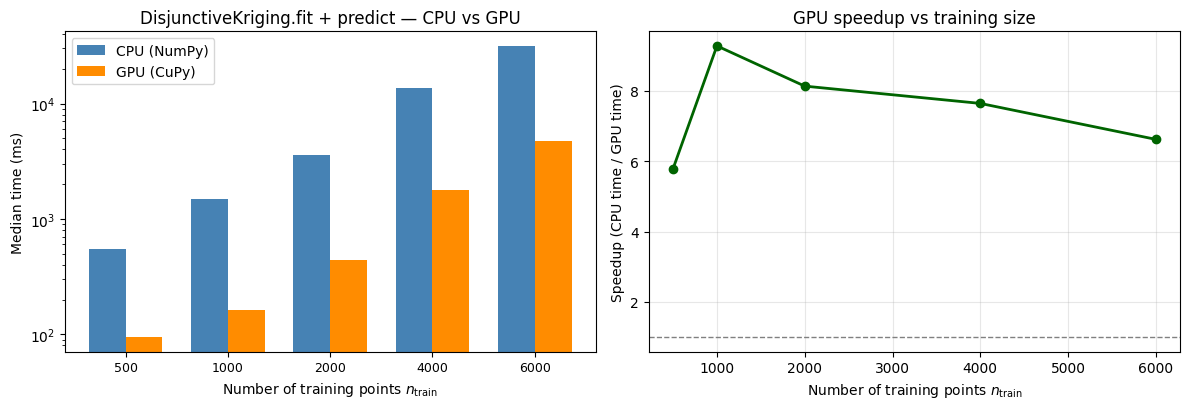

In [18]:
import time

N_REPEATS = 3
N_SIM = 8000
N_PRED = 500
N_HERMITE_T = 8
TRAIN_SIZES = [500, 1000, 2000, 4000, 6000]
rng_sim = np.random.default_rng(42)

pad = 0.15
xmin, xmax = float(coords[:, 0].min()) - pad, float(coords[:, 0].max()) + pad
ymin, ymax = float(coords[:, 1].min()) - pad, float(coords[:, 1].max()) + pad
xy_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_SIM, 2))
xy_pred_t = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED, 2))

df_cond = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "log_cd": np.log(z)})
log_cd_var = float(np.var(np.log(z)))
vario_sgs = [0, 0.05 * log_cd_var, 1.2, 1.2, log_cd_var, "exponential"]

print(f"Simulating {N_SIM:,} Jura-like Cd locations with sgsim")
print(f"  conditioning : {len(z)} samples from data/jura_data.csv")
print(f"  vario        : azimuth=0, nugget={0.05 * log_cd_var:.3f}, range=1.2 km, exponential, log(Cd)")
t0 = time.perf_counter()
sims = sgsim(
    xy_all, df_cond, "x", "y", "log_cd",
    num_points=12, vario=vario_sgs, radius=2.5,
    kriging_type="ordinary", nsim=1, itrans=False, seed=42, quiet=True,
)
sgsim_s = time.perf_counter() - t0
cd_sim = np.exp(np.asarray(sims[0], dtype=float))
print(f"  sgsim wall   : {sgsim_s:.1f} s  (not included in DisjunctiveKriging times)")
print(f"  simulated Cd : [{cd_sim.min():.2f}, {cd_sim.max():.2f}] mg/kg  "
      f"(Jura observed [{z.min():.2f}, {z.max():.2f}])")
print()


def _time_dk(xy_train, z_train, xy_pred, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of DisjunctiveKriging.fit + predict(return_variance=True)."""
    kw = dict(
        model="spherical", n_hermite=N_HERMITE_T, tails="linear",
        use_gpu=use_gpu, variogram_kwargs={"n_lags": 12, "estimator": "matheron"},
    )
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pred))
        DisjunctiveKriging(**kw).fit(xy_train[:k_tr], z_train[:k_tr]).predict(
            xy_pred[:k_pr], return_variance=True
        )
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        dk_m = DisjunctiveKriging(**kw).fit(xy_train, z_train)
        last = dk_m.predict(xy_pred, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of DK fit + predict)")
print(f"n_hermite  : {N_HERMITE_T}  (timing only; mapping in §6 uses N=20)")
print(f"n_pred     : {N_PRED} locations drawn in the Jura bbox")
print(f"n_train    : {TRAIN_SIZES}  (prefixes of the {N_SIM:,} sgsim locations)")
print()

rows = []
for n in TRAIN_SIZES:
    xy_tr, z_tr = xy_all[:n], cd_sim[:n]
    cpu_t, pred_cpu = _time_dk(xy_tr, z_tr, xy_pred_t, use_gpu=False)
    row = {
        "dataset": "Jura (sgsim)",
        "n_train": n,
        "n_pred": N_PRED,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_dk(xy_tr, z_tr, xy_pred_t, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        z_c, se_c = pred_cpu
        z_g, se_g = pred_gpu
        row["match"] = bool(
            np.allclose(z_c, z_g, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(se_c, se_g, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_train"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(int(n)) for n in n_vals], fontsize=9)
axes[0].set_xlabel(r"Number of training points $n_{\mathrm{train}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("DisjunctiveKriging.fit + predict — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of training points $n_{\mathrm{train}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs training size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and DK standard errors from the two backends should **match** (`match = True`). The GPU speedup comes from the $n\times n$ covariance build and solve inside each per-order `SimpleKriging.predict`, not from SGS (simulation is CPU sequential and is excluded from the times). Small $n_{\mathrm{train}}$ can still show a GPU gain because eight independent SK systems are solved; as $n$ grows to 6{,}000 the $O(n^3)$ work keeps the GPU several times faster. Use `use_gpu=USE_GPU` so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 11. Summary and Conclusions

- **Disjunctive kriging** estimates $Z(x_0)$ as a sum of separate functions of each datum, $\sum_i f_i(Z(x_i))$, by expanding the Gaussian anamorphosis in Hermite polynomials and simple-kriging each order under the bi-Gaussian model.
- **`pygstat.DisjunctiveKriging`** implements that recipe: `nscore_forward` for the anamorphosis, `hermite_polynomials` / `hermite_indicator_coefficients` for the basis, and one `SimpleKriging` per order with covariance $\rho_Y(h)^n$.
- On **Jura cadmium**, $N=20$ Hermite terms captured essentially all of the sample variance (`explained_variance_ratio_` near 1). $\varphi_n$ decayed quickly after the first few orders.
- **Held-out scores** were comparable to ordinary kriging of raw Cd, and the two maps were strongly correlated — as they should be, since both are unbiased estimators of the same field. DK is not trying to beat OK on the *mean*; it is trying to get the *nonlinear functionals* right.
- The **probability maps** $P(\mathrm{Cd} > z_c)$ were obtained by recombining the *same* kriged Hermite components. Mean exceedance probability decreased with the cutoff, and test-set Brier scores beat the no-skill (marginal frequency) baseline.
- The **DK standard-error map** is smallest near training samples, as in OK, but it is assembled from the per-order SK variances weighted by $\varphi_n^2$.

- **CPU / GPU.** Global per-order simple kriging (`use_gpu=USE_GPU`) was timed on an SGS-simulated Jura-like Cd field ($n_{\mathrm{train}}$ up to 6{,}000, $n_{\mathrm{pred}}=500$, $N=8$ Hermite orders). Speedup was about **6–9×** on an NVIDIA GeForce RTX 2080 Ti. The 359-sample Jura survey is too small for that comparison.

| Object | Role in this notebook |
|---|---|
| `nscore_forward` | Gaussian anamorphosis $Z=\varphi(Y)$ |
| `hermite_polynomials` | Orthonormal $H_n$ |
| `hermite_indicator_coefficients` | $\chi_n(y_c)$ for $P(Z>z_c)$ |
| `DisjunctiveKriging.fit` | Anamorphosis + $Y$-variogram + per-order SK |
| `predict` | $\hat Z_{DK}$ and DK standard error |
| `predict_proba` | $P(Z>z_c)$ at arbitrary cutoffs |

### Practical takeaways

- Use DK when the variable is **skewed** and you care about **exceedance probabilities** or recoverable means, not only the kriged mean.
- Check `explained_variance_ratio_` and the decay of $\varphi_n$; if they have not settled by $N=20$, raise `n_hermite`.
- The bi-Gaussian assumption is extra structure beyond a Gaussian *histogram*. DK probabilities can still ring near a cutoff; clipping to $[0,1]$ is expected, not a bug.
- Point-support DK does not replace a **change-of-support** model. For block averages, use the discrete Gaussian model (not implemented here).

### Next steps

- Compare these $P(\mathrm{Cd}>1)$ maps with Tutorial 07 (indicator kriging) and Tutorial 09 (soft kriging) on the same Jura survey
- Sequential Gaussian simulation (Tutorial 18) uses the same anamorphosis, then simulates $Y$ rather than kriging its Hermite components


***
## 12. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Rivoirard, J. (1994). *Introduction to Disjunctive Kriging and Nonlinear Geostatistics*. Oxford University Press. | Canonical Hermite-polynomial formulation used here |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | DK, bi-Gaussian model, discrete Gaussian change of support |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Jura Cd case study; nonlinear estimation |
| Wackernagel, H. (2003). *Multivariate Geostatistics* (3rd ed.). Springer. | Anamorphosis, Hermite polynomials, DK |
| Deutsch, C.V. & Journel, A.G. (1998). *GSLIB: Geostatistical Software Library and User's Guide* (2nd ed.). Oxford. | `nscore` / Gaussian anamorphosis used by SGSIM |

### Key papers

| Paper | Contribution |
|---|---|
| Matheron, G. (1976). A simple substitute for conditional expectation: the disjunctive kriging. In *Advanced Geostatistics in the Mining Industry* (pp. 221–236). Reidel. | Original DK |
| Matheron, G. (1976). Forecasting the size of future oil fields. In *Proceedings of the NATO ASI*. | Hermite expansion of nonlinear functionals |
| Rivoirard, J. (1994). *Introduction to Disjunctive Kriging and Nonlinear Geostatistics*. | Worked mining examples, indicator coefficients |

### In this library

| Object | Role |
|---|---|
| `pygstat.DisjunctiveKriging` | Fit / `predict` / `predict_proba` |
| `pygstat.hermite_polynomials` | Orthonormal probabilists' Hermite polynomials |
| `pygstat.disjunctive_kriging.hermite_indicator_coefficients` | $\chi_n(y_c)$ for exceedance |
| `pygstat.nscore.nscore_forward` | Gaussian anamorphosis |
| `pygstat.SimpleKriging` | Per-order kriging engine |
| `tests/test_disjunctive_kriging.py` | Hermite math, synthetic API, Meuse end-to-end |
